## Linear Regression

### Visual Thinking

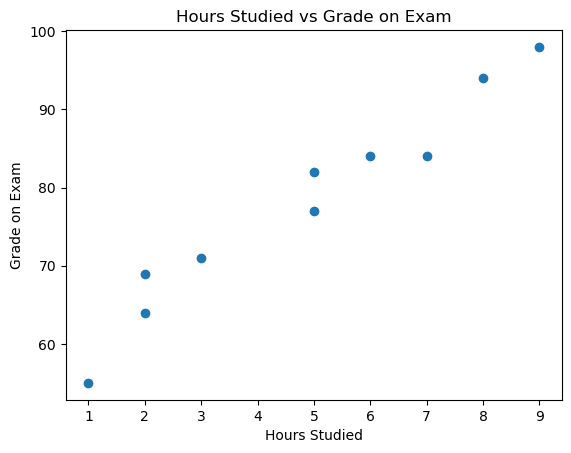

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

hours = np.array([2, 9, 5, 5, 3, 7, 1, 8, 6, 2], dtype=float)
grades = np.array([69, 98, 82, 77, 71, 84, 55, 94, 84, 64], dtype=float)

plt.scatter(hours, grades)
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.title("Hours Studied vs Grade on Exam")
plt.show()

#### Python | Manual Calculation

In [2]:
x = hours
y = grades
x_mean = x.mean()
y_mean = y.mean()
 
beta1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
beta0 = y_mean - beta1 * x_mean

print(f"Mean of X: {x_mean:.2f}")
print(f"Mean of Y: {y_mean:.2f}")
print(f"Intercept (β0): {beta0:.4f}")
print(f"Slope (β1): {beta1:.4f}")
print(f"Fitted line: y_hat = {beta0:.2f} + {beta1:.2f}x")


Mean of X: 4.80
Mean of Y: 77.80
Intercept (β0): 55.0355
Slope (β1): 4.7426
Fitted line: y_hat = 55.04 + 4.74x


In [3]:
new_hours = 4
predicted_grade = beta0 + beta1 * new_hours
print(f"Predicted grade for {new_hours} hours: {predicted_grade:.2f}")

Predicted grade for 4 hours: 74.01


#### Regression in Python scikit-learn

In [4]:
from sklearn.linear_model import LinearRegression

X = hours.reshape(-1, 1)
y = grades
hours_model = LinearRegression()
hours_model.fit(X, y)

print(f"Intercept: {hours_model.intercept_:.4f}")
print(f"Slope: {hours_model.coef_[0]:.4f}")

Intercept: 55.0355
Slope: 4.7426


#### Visualization

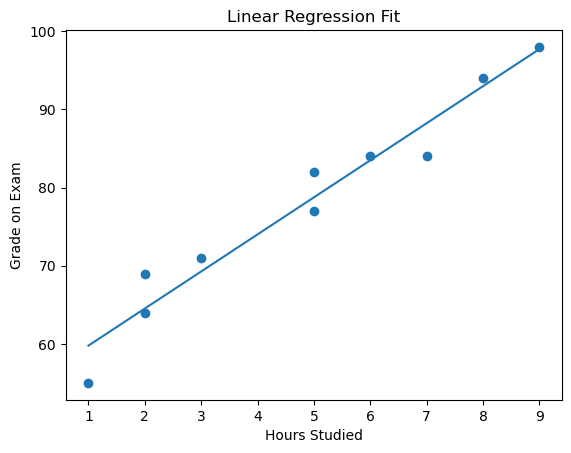

In [6]:
x_line = np.linspace(hours.min(), hours.max(), 100).reshape(-1, 1)
y_line = hours_model.predict(x_line)

plt.scatter(hours, grades)
plt.plot(x_line, y_line)
plt.title("Linear Regression Fit")
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.show()

#### Manual Calculation of $R^2$ and RMSE

In [8]:
y_pred = hours_model.predict(X)
residuals = y - y_pred

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)
rmse = np.sqrt(np.mean(residuals ** 2))

print(f"SS_res: {ss_res:.4f}")
print(f"SS_tot: {ss_tot:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

SS_res: 79.1213
SS_tot: 1599.6000
R-squared: 0.9505
RMSE: 2.8129


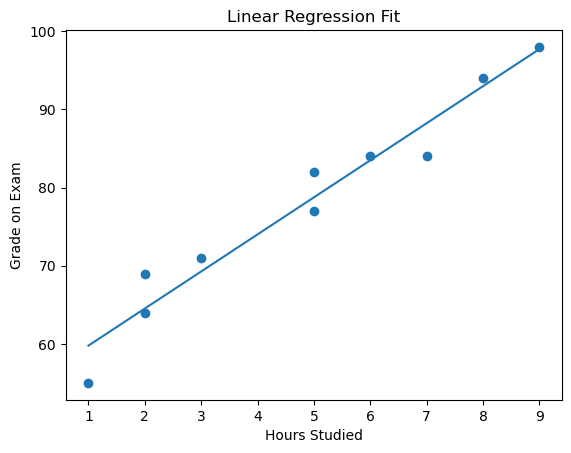

In [9]:
x_line = np.linspace(hours.min(), hours.max(), 100).reshape(-1, 1)
y_line = hours_model.predict(x_line)

plt.scatter(hours, grades)
plt.plot(x_line, y_line)
plt.title("Linear Regression Fit")
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.show()

#### Calculation with Scikit-learn

In [10]:
from sklearn.metrics import r2_score, mean_squared_error

r2_sklearn = r2_score(y, y_pred)
rmse_sklearn = np.sqrt(mean_squared_error(y, y_pred))

print(f"R-squared (sklearn): {r2_sklearn:.4f}")
print(f"RMSE (sklearn): {rmse_sklearn:.4f}")


R-squared (sklearn): 0.9505
RMSE (sklearn): 2.8129


### Business Applications

#### Example 1 | Marketing Spend $\rightarrow$ Sales

In [13]:
import pandas as pd
ads = pd.read_csv('../data/regression/advertising_and_sales.csv')
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [21]:
channel_results = []
for channel in ["tv", "radio", "social_media"]:
    X_channel = ads[[channel]]
    y_sales = ads["sales"]
    channel_model = LinearRegression()
    channel_model.fit(X_channel, y_sales)
    y_hat = channel_model.predict(X_channel)
    r2_channel = r2_score(y_sales, y_hat)
    rmse_channel = np.sqrt(mean_squared_error(y_sales, y_hat))
    channel_results.append({
        "channel": channel,
        "intercept": channel_model.intercept_,
        "slope": channel_model.coef_[0],
        "r_squared": r2_channel,
        "rmse": rmse_channel
    })
    
    pd.DataFrame(channel_results).round(4)

In [20]:
pd.DataFrame(channel_results).round(4)

,channel,intercept,slope,r_squared,rmse
0,tv,-132.4925,3.5615,0.9990,2948.5897
1,radio,40586.8007,8.3616,0.7545,46081.4060
2,social_media,118672.5717,22.1879,0.2782,79019.9030


In [23]:
ads[["tv", "radio", "social_media", "sales"]].corr().round(3)

,tv,radio,social_media,sales
tv,1.000,0.869,0.528,0.999
radio,0.869,1.000,0.606,0.869
social_media,0.528,0.606,1.000,0.527
sales,0.999,0.869,0.527,1.000


In [24]:
import plotly.express as px

corr = ads[["tv", "radio", "social_media", "sales"]].corr().round(3)
fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
)
fig.update_layout(
    title="Correlation Matrix",
    xaxis_title="",
    yaxis_title=""
)
fig.show()

#### Multiple regression

In [25]:
X_multi_num = ads[["tv", "radio", "social_media"]]
y_sales = ads["sales"]

multi_num_model = LinearRegression()
multi_num_model.fit(X_multi_num, y_sales)
y_hat_multi_num = multi_num_model.predict(X_multi_num)

multi_num_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi_num.columns),
    "coefficient": [multi_num_model.intercept_] + list(multi_num_model.coef_)
}).round(4)

multi_num_r2 = r2_score(y_sales, y_hat_multi_num)
multi_num_rmse = np.sqrt(mean_squared_error(y_sales, y_hat_multi_num))

print(f"R-squared: {multi_num_r2:.4f}")
print(f"RMSE: {multi_num_rmse:.2f}")

R-squared: 0.9990
RMSE: 2948.54


In [26]:
multi_num_results

,feature,coefficient
0,intercept,-133.9630
1,tv,3.5626
2,radio,-0.0040
3,social_media,0.0050


In [30]:
ads["influencer"] = pd.Categorical(
    ads["influencer"],
    categories=["Mega", "Macro", "Micro", "Nano"]
)
X_multi = pd.get_dummies(
    ads[["tv", "radio", "social_media", "influencer"]],
    drop_first=True,
    dtype=int
)

multi_model = LinearRegression()
multi_model.fit(X_multi, y_sales)
y_hat_multi = multi_model.predict(X_multi)

multi_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi.columns),
    "coefficient": [multi_model.intercept_] + list(multi_model.coef_)
}).round(4)

multi_r2 = r2_score(y_sales, y_hat_multi)
multi_rmse = np.sqrt(mean_squared_error(y_sales, y_hat_multi))

print(f"R-squared: {multi_r2:.4f}")
print(f"RMSE: {multi_rmse:.2f}")


R-squared: 0.9990
RMSE: 2948.31


In [31]:
multi_results

,feature,coefficient
0,intercept,-91.7009
1,tv,3.5626
2,radio,-0.0039
3,social_media,0.0045
4,influencer_Macro,-11.6028
5,influencer_Micro,-68.4840
6,influencer_Nano,-85.5007


### Mini Homework

#### Try to create a loop which will the exacltly thee same for Open, High, Low